# Unbinned likelihood-based forward-folding analysis

In tutorial 04 we built a Poisson likelihood over *binned* counts: we sorted the detected photons into measured-energy bins $\Delta E_{m_k}$, and compared the observed counts $N_k$ in each bin to the expectation $\lambda_k(\Theta)$.

Binning is convenient, but it isn't free. Choosing bins throws away information (all events in a bin are treated as identical, regardless of where exactly they fall within it), and when there are only a few events, or the quantity you care about is continuous, binning can become wasteful. In this tutorial we'll perform the same kind of forward-folding maximum likelihood fit, but without ever building a histogram of the data -- an *unbinned* (or event-by-event) likelihood analysis.

## From binned to unbinned

Recall from tutorial 04 that the number of events $N_k$ landing in a bin where $\lambda_k(\Theta)$ are expected is Poisson-distributed:

$$P(N_k;\lambda_k) = \frac{e^{-\lambda_k}\lambda_k^{N_k}}{N_k!}$$

Crucially, this formula is valid for *any* value of $\lambda_k$, no matter how small -- as $\lambda_k \to 0$ it doesn't break down, it just says the bin is overwhelmingly likely to be empty. That means we're free to make our bins as narrow as we like without ever leaving Poisson statistics.

So let's do exactly that: shrink every bin until it's narrow enough to hold either 0 or 1 events (splitting an occupied bin in half never merges two events into it, so this is always achievable). The full likelihood is just the product of the Poisson probability of every bin, and with only two possible outcomes per bin it splits into two pieces:

$$\mathcal{L}(\Theta) = \prod_{k \,:\, N_k = 0} \underbrace{e^{-\lambda_k(\Theta)}}_{P(0;\lambda_k)} \;\; \times \!\!\prod_{k \,:\, N_k = 1} \underbrace{\lambda_k(\Theta)\, e^{-\lambda_k(\Theta)}}_{P(1;\lambda_k)}$$

Taking the log turns the products into sums:

$$\log\mathcal{L}(\Theta) = -\!\!\sum_{k \,:\, N_k = 0}\!\! \lambda_k(\Theta) \; - \!\!\sum_{k \,:\, N_k = 1}\!\! \lambda_k(\Theta) \; + \!\!\sum_{k \,:\, N_k = 1}\!\! \log\left(\lambda_k(\Theta)\right)$$

The first two sums together run over *every* bin, occupied or not (since each bin is one or the other), so they're just $-\sum_k \lambda_k(\Theta)$. As the bins keep shrinking this sum converges to the integral of the expectation density over the whole range, $\mu(\Theta) = \int \lambda(x;\Theta)\,dx$ -- the total number of expected events. No approximation is needed to get here, only relabeling: we've exactly split a sum over all bins into a sum over empty ones and a sum over occupied ones. What's left is:

$$\log \mathcal{L}(\Theta) = -\mu(\Theta) + \sum_i \log\left(\lambda(x_i;\Theta)\right)$$

where $\lambda(x;\Theta)$ is the *expectation density* -- expected events per unit of $x$ -- and the last sum runs over every individually observed value $x_i$ (in our case, the measured energy of each detected photon), not over bins.

This is exactly what `gammaraytoys.analysis.unbinned_log_likelihood` computes, given the expectation density evaluated at each data point and the total expected number of events:

```python
unbinned_log_likelihood(expectation_density, total_expectation)
```

## Setting up the toy problem

We'll reuse the same on-axis detector as tutorial 06, along with the effective area $A_{eff}(E_i)$ and energy-dispersion PDF $\mathrm{pdf}(E_m|E_i)$ we built there (`response_energy_relative_onaxis_traddet.h5`). Since both are stored as smoothly interpolated histograms, we can evaluate them at *any* measured energy -- exactly what we need for an unbinned analysis.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.detectors import Simulator, SimpleTraditionalReconstructor, PointSource, MonoenergeticSpectrum
from gammaraytoys.analysis import unbinned_log_likelihood, LogLikeGrid
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

# Detector
det = ToyTracker2D(material = 'Ge',
                   layer_length = 10*u.m,
                   layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                   layer_thickness = 1*u.cm,
                   energy_resolution = 0.03,
                   energy_threshold = 20*u.keV)

# Effective area and energy-dispersion PDF from tutorial 06
Aeff = Histogram.open("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'Aeff')
energy_pdf = Histogram.open("instrument_response/response_energy_relative_onaxis_traddet.h5", name = 'PDF')

### Simulating the (unbinned) data

Let's inject a monoenergetic line source and simulate the individually detected photons. This time we won't histogram the result: we'll just keep the plain list of measured energies, one entry per detected photon, exactly like a real detector would give us.

In [2]:
import contextlib, io

np.random.seed(0)

line_energy = 2*u.MeV
flux = 2e-6/u.cm/u.s
duration = 10*u.hr

source = PointSource(offaxis_angle = 0*u.deg,
                     spectrum = MonoenergeticSpectrum(energy = line_energy),
                     flux = flux)

reco = SimpleTraditionalReconstructor()
sims = Simulator(detector = det, sources = source, reconstructor = reco)

signal_energies = []
with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    for sim_event, reco_event in sims.run_events(duration = duration):
        if reco_event.triggered:
            signal_energies.append(reco_event.energy.to_value(u.MeV))
signal_energies = u.Quantity(signal_energies, u.MeV)

print(f"{signal_energies.size} signal photons detected")

43 signal photons detected


No real detector is background free. For simplicity, we'll assume a background that's flat over some energy window surrounding the line, and simulate it event-by-event too, rather than as counts in a histogram:

In [3]:
bkg_window = [0.5, 3.5]*u.MeV  # Region we'll consider for the analysis
bkg_rate = 6e-3*u.Hz           # Total background rate within that window

n_bkg = np.random.poisson((bkg_rate*duration).to_value(''))
bkg_energies = np.random.uniform(bkg_window[0].value, bkg_window[1].value, size = n_bkg)*u.MeV

print(f"{n_bkg} background photons detected")

228 background photons detected


271 total photons in the dataset


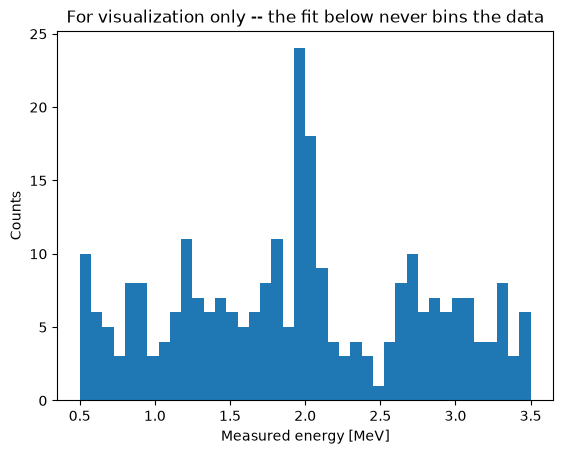

In [4]:
# The "data" is simply the full list of measured energies -- no histogram involved.
data_energies = u.Quantity(np.concatenate([signal_energies, bkg_energies]))

print(f"{data_energies.size} total photons in the dataset")

# Just for visualization -- the fit below never bins the data
fig,ax = plt.subplots()
ax.hist(data_energies.to_value(u.MeV), bins = 40, range = (bkg_window[0].value, bkg_window[1].value))
ax.set_xlabel("Measured energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title("For visualization only -- the fit below never bins the data");

## Building the expectation density

Just like in the binned case, we need a model for the expected number of events, but now expressed as a *density* over the measured energy, $\lambda(E_m;\Theta)$, together with its integral, $\mu(\Theta)$.

In general the true photon energy $E_i$ isn't known event by event, only its distribution -- the source spectrum $dN/dE_i$ -- is. So the signal density at a given measured energy has to account for photons of *every* true energy that could have produced it, weighted by how likely each one is to be emitted and by how the detector responds to it:

$$\lambda_{sig}(E_m;\Theta) = T \int dE_i \, \frac{dN}{dE_i}(\Theta) \, A_{eff}(E_i) \, \mathrm{pdf}(E_m|E_i)$$

Our source, though, is monoenergetic: every photon is emitted at the same energy, so $dN/dE_i = F \cdot \delta(E_i - E_i^{hyp})$, a Dirac delta at the hypothesized line energy. The integral above then simply picks out the integrand at $E_i = E_i^{hyp}$, collapsing to:

$$\lambda_{sig}(E_m) = F \cdot T \cdot A_{eff}(E_i^{hyp}) \cdot \mathrm{pdf}(E_m|E_i^{hyp})$$

where $F$ is the flux, $T$ the exposure time, and $\mathrm{pdf}(E_m|E_i)$ the energy-dispersion PDF from tutorial 06, normalized so that $\int \mathrm{pdf}(E_m|E_i)\,dE_m = 1$. Outside the range covered by the interpolated response we simply set the signal density to 0. (For a source with a continuous spectrum, like the power law in tutorial 04, you'd need to actually carry out the integral over $E_i$ -- for instance by discretizing the spectrum the way `SpectralResponse.expected_counts` does for the binned case.)

For the flat background, the density is just the total expected background counts spread evenly over the window, $\lambda_{bkg}(E_m) = N_{bkg}(\Theta)/\Delta E_{window}$.

In [5]:
def signal_expectation(energies, flux_hyp, Ei_hyp):
    """Signal expectation density [1/MeV] at each of `energies`, and the total expected signal counts"""

    Ei_broadcast, energies_broadcast = np.broadcast_arrays(Ei_hyp, energies, subok = True)

    delta_frac = ((energies_broadcast - Ei_broadcast)/Ei_broadcast).to_value('')

    in_response = ((delta_frac >= energy_pdf.axes['EmDeltaFrac'].lo_lim) &
                   (delta_frac <= energy_pdf.axes['EmDeltaFrac'].hi_lim))

    density = np.zeros(energies.size)/u.MeV
    density[in_response] = energy_pdf.interp(Ei_broadcast[in_response], delta_frac[in_response])

    total_signal = (flux_hyp * duration * Aeff.interp(Ei_hyp)).to_value('')

    return total_signal*density, total_signal

def bkg_expectation(energies, bkg_rate_hyp):
    """Background expectation density [1/MeV] at each of `energies`, and the total expected background counts"""

    total_bkg = (bkg_rate_hyp * duration).to_value('')

    density = np.full(energies.size, total_bkg/(bkg_window[1]-bkg_window[0]).to_value(u.MeV))/u.MeV

    return density, total_bkg

## The unbinned likelihood function

In [6]:
def log_like_fun(flux_hyp, Ei_hyp, bkg_rate_hyp):

    sig_density, mu_sig = signal_expectation(data_energies, flux_hyp, Ei_hyp)
    bkg_density, mu_bkg = bkg_expectation(data_energies, bkg_rate_hyp)

    total_density = (sig_density + bkg_density).to_value(1/u.MeV)
    total_expectation = mu_sig + mu_bkg

    return unbinned_log_likelihood(total_density, total_expectation)

Just like in the binned case, we can use `LogLikeGrid` to scan a grid of hypotheses -- flux, line energy, and background rate -- and find the maximum likelihood estimate, all without ever putting a single event in a bin:

In [7]:
log_like = LogLikeGrid([Axis(np.geomspace(5e-7, 6e-6, 30)/u.cm/u.s, label = 'flux', scale = 'log'),
                        Axis(np.linspace(1.94, 2.06, 30)*u.MeV, label = 'Ei'),
                        Axis(np.geomspace(2e-3, 1.5e-2, 20)*u.Hz, label = 'bkg', scale = 'log')])

with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    log_like.compute(log_like_fun)

In [8]:
popt = log_like.optimal_parameters()
print(f"Flux best estimate        = {popt[0]:.2}  (injected {flux:.2})")
print(f"Line energy best estimate = {popt[1]:.3}  (injected {line_energy:.3})")
print(f"Bkg rate best estimate    = {popt[2]:.2}  (injected {bkg_rate:.2})")

Flux best estimate        = 2.4e-06 1 / (cm s)  (injected 2e-06 1 / (cm s))
Line energy best estimate = 2.0 MeV  (injected 2.0 MeV)
Bkg rate best estimate    = 0.0061 Hz  (injected 0.006 Hz)


As we did for the background nuisance parameter in tutorial 04, we profile it out to visualize the flux vs. line-energy likelihood surface:

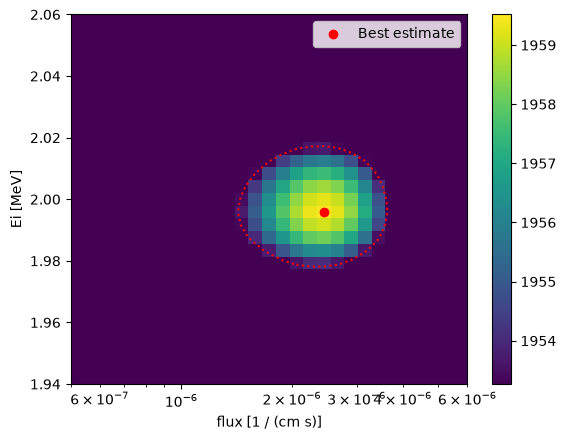

In [9]:
profile_log_like = log_like.maximum('bkg')
profile_log_like.plot_ts()

## Detection significance

To turn this into a detection significance we need a null hypothesis. As before, the natural choice is background-only, i.e. the flux fixed to 0:

In [10]:
def log_like0_fun(bkg_rate_hyp):
    bkg_density, mu_bkg = bkg_expectation(data_energies, bkg_rate_hyp)
    return unbinned_log_likelihood(bkg_density.to_value(1/u.MeV), mu_bkg)

log_like0 = LogLikeGrid(Axis(np.geomspace(2e-3, 1.5e-2, 20)*u.Hz, label = 'bkg', scale = 'log'))
with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    log_like0.compute(log_like0_fun)

In [11]:
from scipy.stats import chi2, norm

ts_detection = 2*(log_like.maximum() - log_like0.maximum())
pvalue = chi2.sf(ts_detection, df = log_like.ndof - log_like0.ndof)
significance = norm.isf(pvalue)

print(f"TS = {ts_detection:.1f}")
print(f"Significance = {significance:.1f} sigma")

TS = 60.6
Significance = 7.4 sigma


Even though the background outnumbers the photopeak counts several times over, the line stands out clearly because it's confined to a much narrower range of measured energies than the flat background. Try lowering `flux` a few cells above (and re-running the notebook) to see how the significance degrades as the signal becomes marginal.

<div class="alert alert-block alert-info">
<b>Exercise: Binned vs. unbinned</b>

Repeat this analysis, but this time histogram <code>data_energies</code> into a <code>Histogram</code> with, say, 30-100 bins across <code>bkg_window</code>, and fit it with <code>poisson_binned_log_likelihood</code> instead (you'll need to integrate the signal and background expectation densities over each bin). Compare the best-fit parameters and the TS you get from the binned vs. the unbinned approach. Then progressively lower the injected flux (or the exposure time) until only a handful of signal photons remain: which approach holds up better with very little data, and why?
</div>

<div class="alert alert-block alert-info">
<b>Exercise: A more realistic background</b>

We assumed a flat background for simplicity. Try sampling <code>bkg_energies</code> from a different shape instead (e.g. exponentially falling), and update <code>bkg_expectation</code> to match. Since the expectation density only ever needs to be evaluated at the location of each detected photon, using a more realistic shape is no harder in the unbinned case than the flat one was -- one of the advantages of not committing to a fixed set of bins ahead of time.
</div>